# DEIMoS -- Monte Carlo Consistency / Verification Analysis

Plots the output of `monte_carlo_verify.py` -- 500 random large-angle slews
(90-179 deg, uniform random axis) replayed under both `wie_eigenaxis` and
`pid_example`, matched pair by pair (same slew, both controllers).

**On "generations":** this study has no GA/generations -- there are only
*runs*. The x-axis below is **run index** (`run_id`, 0-499, the order the
random trials were drawn in), which is the natural reading of "vs
generations" for this dataset. A flat, driftless scatter across run index is
itself part of the consistency claim: it says the controller's behaviour
doesn't depend on when in the random sequence a slew happened to be drawn,
only on the slew itself.

One section per controller, four plots each, in the order requested: SSE,
control effort, settling time, then the slew's eigenangle (`angle_deg` --
the rotation angle of the sampled axis-angle quaternion, which by
construction *is* the shortest-path/eigenaxis angle from the initial
attitude to the identity target). A shaded band shows mean +/- 1 std so
"consistent" has a visual meaning, not just a claim.

A short bonus section at the end plots each metric **against the slew
angle** rather than run index -- the more physically meaningful view of
"does difficulty scale with how large the slew was" -- plus a head-to-head
summary table.


## 1 -- Load the data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deimos.viz.style import BG, FG, GRID, COLORS, CYCLE, _new_fig

CSV_PATH = "../runs/monte_carlo_small_angle_hold.csv"

df = pd.read_csv(CSV_PATH)
print(f"{len(df)} rows, controllers: {sorted(df['controller'].unique())}")
df.groupby("controller")["settled"].agg(["mean", "count"]).rename(columns={"mean": "settled_frac"})


388 rows, controllers: ['wie_eigenaxis', 'wie_eigenaxis_hold']


,settled_frac,count
controller,,
wie_eigenaxis,1.0,195
wie_eigenaxis_hold,1.0,193


In [2]:
CONTROLLERS = ["wie_eigenaxis"]
by_controller = {c: df[df["controller"] == c].sort_values("run_id").reset_index(drop=True)
                 for c in CONTROLLERS}

METRICS = [
    ("sse_deg", "SSE (deg)", "#ff4b4b"),
    ("control_effort_Nms", "Control effort (N m s)", "#4bff7a"),
    ("settling_time_s", "Settling time (s)", "#4b9bff"),
    ("angle_deg", "Slew eigenangle (deg)", "#ffb84b"),
]


## 2 -- Plotting helper

One figure per controller: four stacked panels, metric vs run index, with a
mean +/- 1 std band. Unsettled runs (`settled == False`, `settling_time_s`
is NaN) are dropped from that one panel only rather than breaking the plot
-- none occurred in this dataset (see the `settled_frac` table above), but
the code doesn't assume that stays true for a re-run with a harder
--angle-max or a different controller.


In [3]:
def plot_controller_section(name, sub):
    fig, axes = _new_fig(len(METRICS), figsize=(10, 2.6))
    fig.suptitle(f"Monte Carlo Verification -- {name}  (n={len(sub)} random large slews)",
                 color=FG, fontsize=12, y=1.01)

    for ax, (col, label, color) in zip(axes, METRICS):
        valid = sub.dropna(subset=[col])
        x, y = valid["run_id"].to_numpy(), valid[col].to_numpy()

        mean, std = y.mean(), y.std()
        ax.axhspan(mean - std, mean + std, color=color, alpha=0.12, linewidth=0)
        ax.axhline(mean, color=color, linestyle="--", linewidth=1.2, alpha=0.9,
                   label=f"mean={mean:.4g}  std={std:.4g}")
        ax.scatter(x, y, s=10, color=color, alpha=0.55, edgecolors="none")

        n_dropped = len(sub) - len(valid)
        if n_dropped:
            ax.set_title(f"{label}  ({n_dropped} not settled, excluded)", color=FG, fontsize=9, loc="right")

        ax.set_ylabel(label)
        ax.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID, fontsize=8, loc="upper right")

    axes[-1].set_xlabel("run index (generation)")
    fig.tight_layout()
    plt.show()
    return fig


## 3a -- Section 1: `wie_eigenaxis`

Case 1 (mu=1, K=k*J), globally stable for any k,d>0, wheel-momentum
decoupling on. Expect a tight, flat scatter across all four panels: the
eigenaxis law's closed loop is `omega_dot = -d*omega - s*k*q_ev` with `J`
cancelled out entirely, so nothing here should depend on which random axis
was drawn -- only mildly on the (also random) slew angle via settling time
and effort scaling with the initial error magnitude.


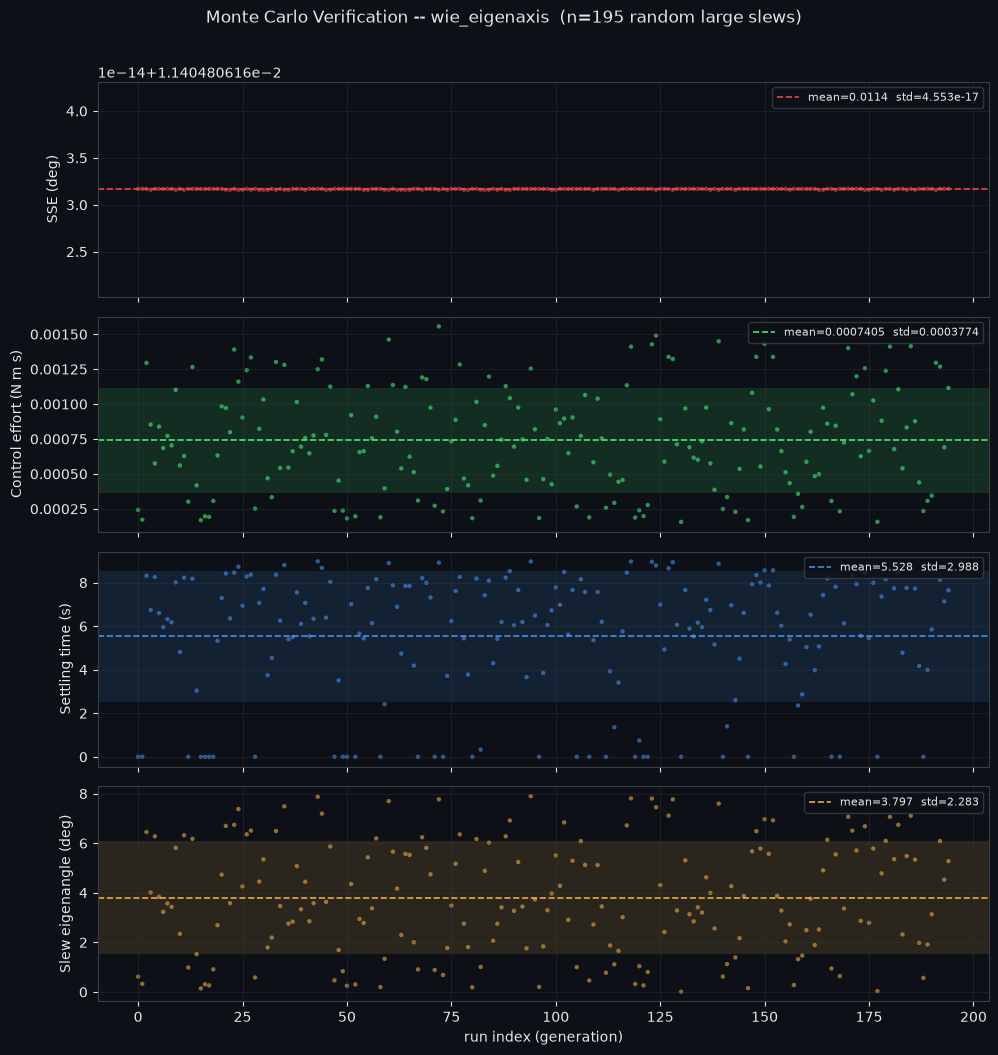

In [4]:
_ = plot_controller_section("wie_eigenaxis", by_controller["wie_eigenaxis"])


## 4 -- Bonus: metric vs slew angle, and a head-to-head summary

`run_id` has no physical meaning (it's just draw order); the slew's
**eigenangle** does. Plotting against `angle_deg` instead is the more
scientifically meaningful "does this get harder for bigger slews" check,
and it's the same data already loaded above -- no re-run needed.


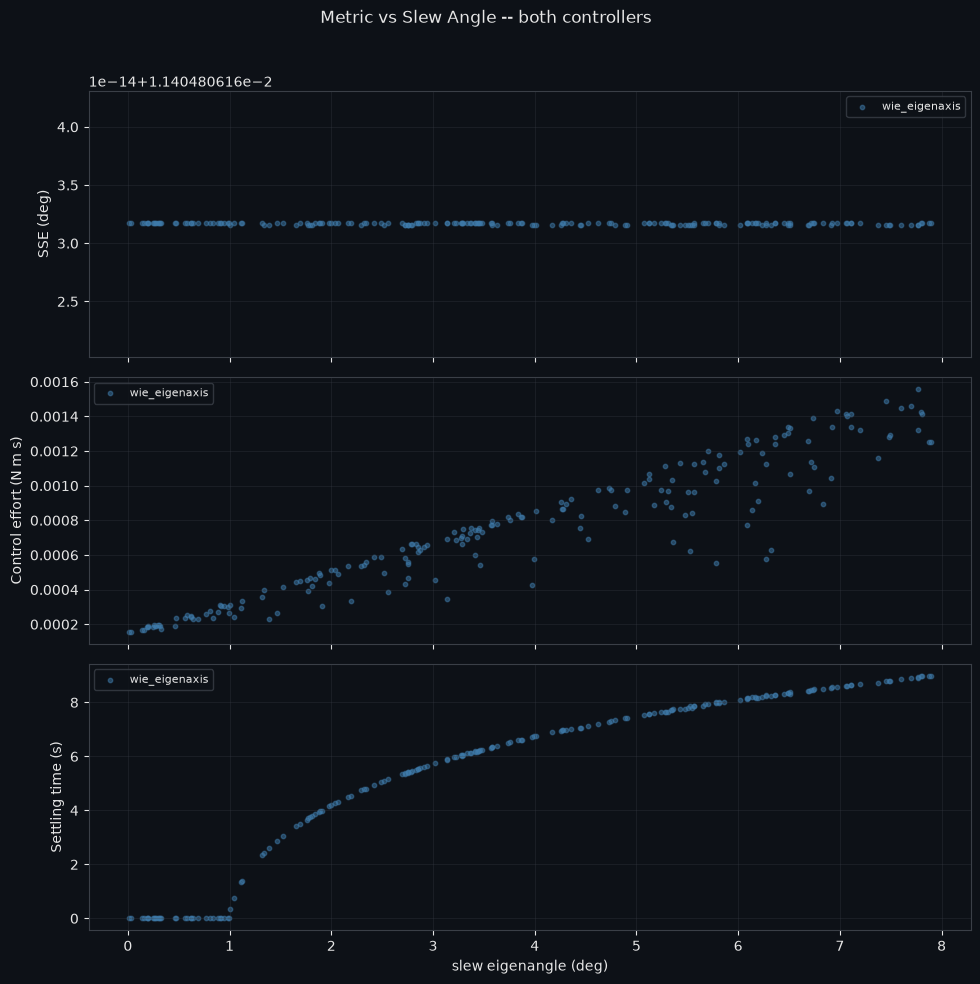

In [5]:
fig, axes = _new_fig(3, figsize=(10, 3.2))
for ax, (col, label, _) in zip(axes, METRICS[:3]):
    for i, cname in enumerate(CONTROLLERS):
        sub = by_controller[cname].dropna(subset=[col])
        ax.scatter(sub["angle_deg"], sub[col], s=10, alpha=0.5,
                   color=CYCLE[i % len(CYCLE)], label=cname)
    ax.set_ylabel(label)
    ax.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID, fontsize=8)
axes[-1].set_xlabel("slew eigenangle (deg)")
fig.suptitle("Metric vs Slew Angle -- both controllers", color=FG, fontsize=12, y=1.02)
fig.tight_layout()
plt.show()


In [6]:
summary = (df.groupby("controller")[["settling_time_s", "control_effort_Nms", "sse_deg",
                                       "saturation_fraction", "mean_eigenaxis_deviation_deg"]]
             .agg(["mean", "std"]))
summary.columns = [f"{a}_{b}" for a, b in summary.columns]
print(summary.T)


controller                         wie_eigenaxis  wie_eigenaxis_hold
settling_time_s_mean                5.528359e+00            5.265596
settling_time_s_std                 2.995484e+00            2.828316
control_effort_Nms_mean             7.404536e-04            0.000749
control_effort_Nms_std              3.784038e-04            0.000386
sse_deg_mean                        1.140481e-02            0.012150
sse_deg_std                         4.856539e-17            0.007163
saturation_fraction_mean            0.000000e+00            0.000000
saturation_fraction_std             0.000000e+00            0.000000
mean_eigenaxis_deviation_deg_mean   8.022766e-01            1.073512
mean_eigenaxis_deviation_deg_std    5.011110e+00            6.825982
